# 03 - Prophet Forecasting
Forecast future music streaming trends.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

In [2]:
# Load dataset
df = pd.read_csv('../data/spotify_final_cleaned.csv')

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Prepare time series data
trend_data = (
    df.groupby('Date')['Streams']
    .sum()
    .reset_index()
)

trend_data.columns = ['ds', 'y']

print(trend_data.head())

          ds           y
0 2024-01-25  2574574141
1 2024-02-29  2601635706
2 2024-03-28  2763540534
3 2024-04-25  3605841989
4 2024-05-30  3012544120


In [3]:
# Build Prophet model
model = Prophet()

model.fit(trend_data)

# Create future dataframe
future = model.make_future_dataframe(
    periods=365
)

# Forecast
forecast = model.predict(future)

print(forecast[['ds', 'yhat']].tail())

11:18:19 - cmdstanpy - INFO - Chain [1] start processing


11:18:19 - cmdstanpy - INFO - Chain [1] done processing


            ds          yhat
389 2027-05-03  2.828397e+09
390 2027-05-04  2.751497e+09
391 2027-05-05  2.654070e+09
392 2027-05-06  2.539164e+09
393 2027-05-07  2.410237e+09


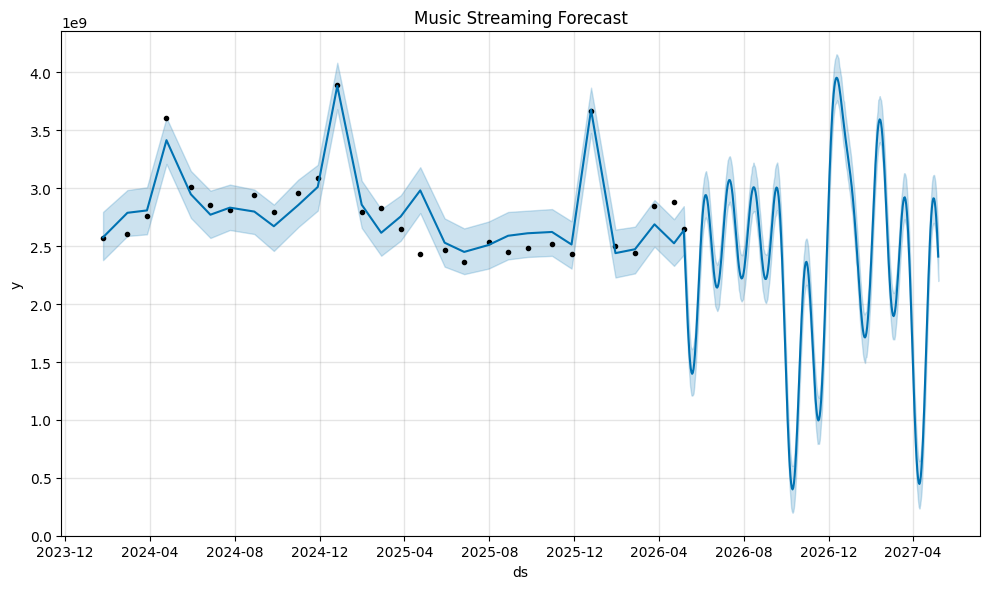

In [4]:
# Plot forecast
os.makedirs('../outputs', exist_ok=True)

fig = model.plot(forecast)

plt.title('Music Streaming Forecast')

plt.tight_layout()
plt.savefig('../outputs/forecasting_result.png')
plt.show()